# Project

## Task 1

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv('dataset.csv')

In [5]:
# View the basic structure
print("Dataset Info")
df.info()

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 131.4 KB


In [7]:
print("First 5 Rows")
display(df.head())

First 5 Rows


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Task 2

In [10]:
# Even if a dataset looks clean, I always drop duplicates first just to be safe.
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Dropped {initial_rows - len(df)} duplicate rows.")

Dropped 0 duplicate rows.


In [11]:
# Format Data Correctly
df['Date'] = pd.to_datetime(df['Date'])

In [13]:
# Handle Missing Values
# From the info check, only 'CouponCode' has missing values (309 of them)
# Logically, this isn't missing data; it just means the customer didn't apply a discount
# Instead of deleting these valuable rows, I'll fill the empty spaces with 'No Coupon'
df['CouponCode'] = df['CouponCode'].fillna('No Coupon')

In [15]:
# Final Sanity Check
# Making sure everything is completely clean before moving to analysis
print("Missing Values After Cleaning")
display(df.isnull().sum())

Missing Values After Cleaning


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

## Task 3

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
sns.set_theme(style="whitegrid")

In [26]:
# Calculate Basic Statistics (The Math)
print("Basic Statistical Summary")
display(df.describe().round(2))

Basic Statistical Summary


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.00,1200.00,1200.00,1200.00
mean,2024-03-22 16:58:48,2.95,356.41,5.48,1053.97
min,2023-01-01 00:00:00,1.00,11.39,1.00,11.39
25%,2023-08-03 18:00:00,2.00,186.06,4.00,410.52
50%,2024-03-23 00:00:00,3.00,364.21,5.00,823.62
75%,2024-11-08 12:00:00,4.00,521.57,7.00,1578.48
max,2025-06-30 00:00:00,5.00,699.93,10.00,3456.40
std,NaN,1.41,197.18,2.28,819.86


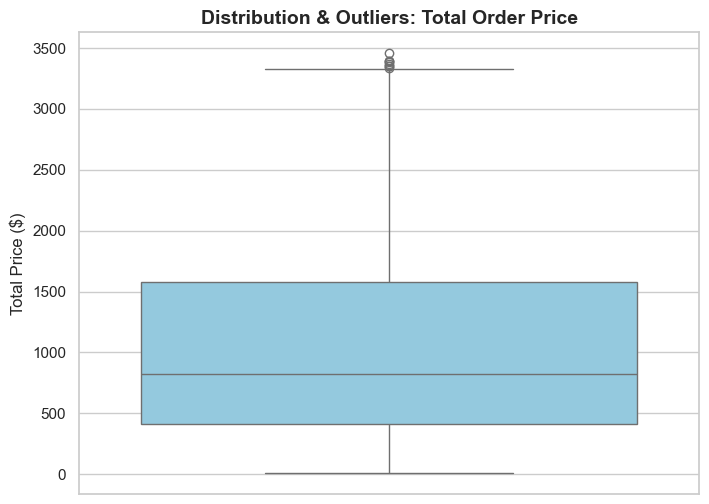

In [60]:
# CHART 1: Boxplot to spot OUTLIERS
plt.figure(figsize=(8, 6))

sns.boxplot(y=df['TotalPrice'], color='skyblue')
plt.title('Distribution & Outliers: Total Order Price', fontsize=14, fontweight='bold')
plt.ylabel('Total Price ($)')

plt.show()

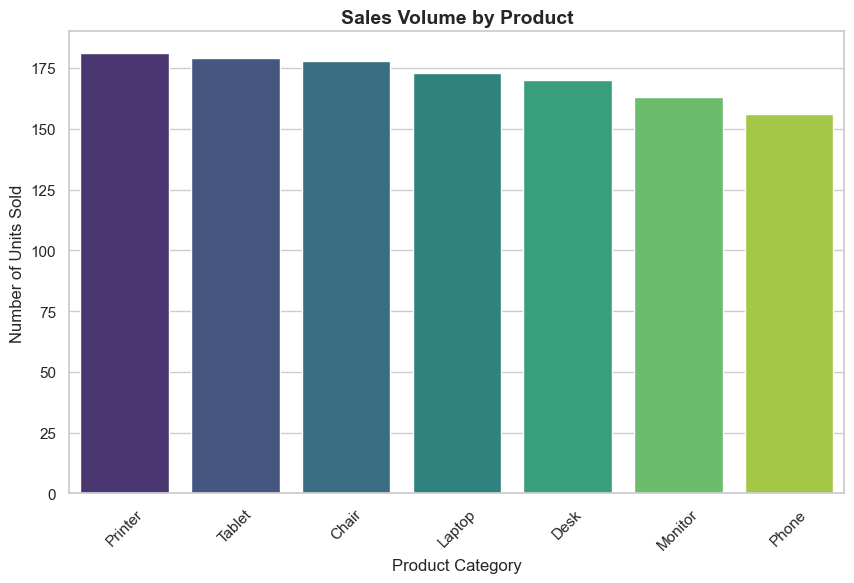

In [63]:
# CHART 2: Bar chart to find the BEST SELLERS
plt.figure(figsize=(10, 6))

product_counts = df['Product'].value_counts()
sns.barplot(x=product_counts.index, y=product_counts.values, palette='viridis', hue=product_counts.index, legend=False)

plt.title('Sales Volume by Product', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Number of Units Sold')
plt.xticks(rotation=45) # Tilt the text so it fits perfectly

plt.show()

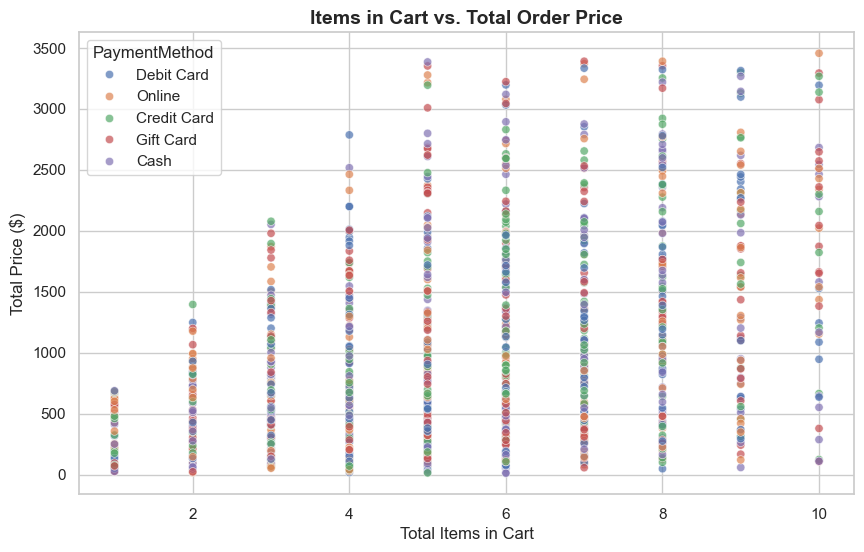

In [64]:
# CHART 3: Scatterplot to track CART BEHAVIOR
plt.figure(figsize=(10, 6)) # Wide and spacious

sns.scatterplot(x='ItemsInCart', y='TotalPrice', hue='PaymentMethod', data=df, alpha=0.7)

plt.title('Items in Cart vs. Total Order Price', fontsize=14, fontweight='bold')
plt.xlabel('Total Items in Cart')
plt.ylabel('Total Price ($)')

plt.show()

## Task 4

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [66]:
# Set a professional style for the dashboard
sns.set_theme(style="whitegrid")

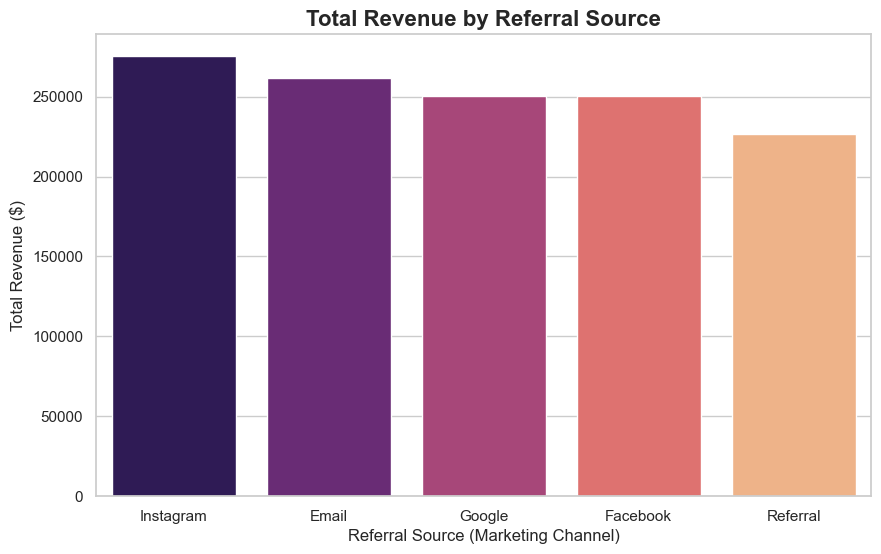

In [67]:
# CHART 1: Total Revenue by Referral Source
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6)) # Spacious individual size

# Calculate total money made from each marketing channel
revenue_by_source = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)

sns.barplot(x=revenue_by_source.index, y=revenue_by_source.values, palette='magma', hue=revenue_by_source.index, legend=False)
plt.title('Total Revenue by Referral Source', fontsize=16, fontweight='bold')
plt.xlabel('Referral Source (Marketing Channel)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)

plt.show()

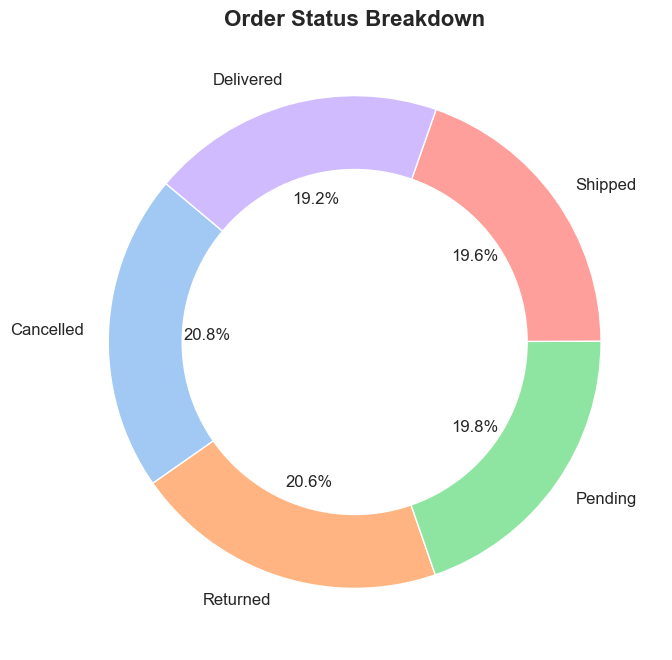

In [68]:
# CHART 2: Order Status Breakdown
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8)) # Spacious square size

# Count how many orders are delivered, shipped, returned, etc.
status_counts = df['OrderStatus'].value_counts()
colors = sns.color_palette('pastel')[0:len(status_counts)]

# Create a pie chart, then add a white circle in the middle to make it a donut
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, textprops={'fontsize': 12})
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Order Status Breakdown', fontsize=16, fontweight='bold')
plt.show()

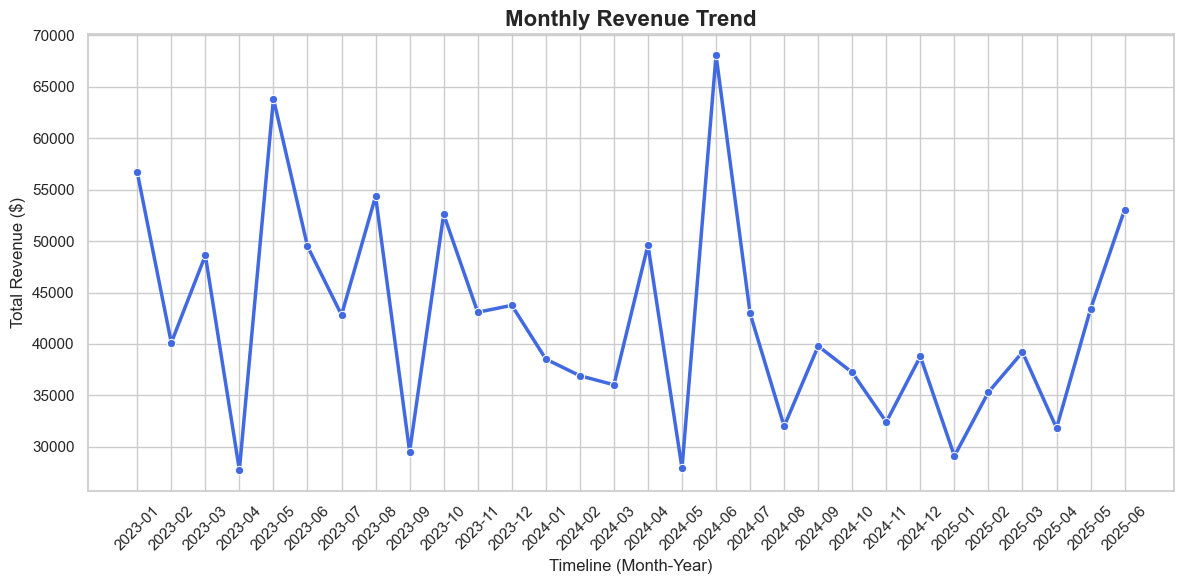

In [69]:
# CHART 3: Monthly Revenue Trend
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6)) # Wide and spacious for a timeline

# Extract the Year and Month so we can group the sales data cleanly
df['YearMonth'] = df['Date'].dt.to_period('M').astype(str)
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum().reset_index()

sns.lineplot(x='YearMonth', y='TotalPrice', data=monthly_sales, marker='o', color='royalblue', linewidth=2.5)

plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Timeline (Month-Year)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45) # Tilt the dates so they don't overlap

plt.tight_layout()
plt.show()

## Task 5

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [71]:
# Define Features (X) and Target (y)
# We want to predict the TotalPrice.
X = df[['ItemsInCart', 'Product', 'PaymentMethod', 'ReferralSource', 'CouponCode']]
y = df['TotalPrice']

In [72]:
# Convert Text Data to Numbers (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True)

In [73]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [74]:
# Initialize and Train the Model
print("Training the Random Forest Regressor...\n")
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

Training the Random Forest Regressor...



,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [75]:
# Make Predictions and Evaluate
predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)

print("Predictive Model Results")
print(f"Mean Absolute Error (MAE): ₹{mae:.2f}")

Predictive Model Results
Mean Absolute Error (MAE): ₹646.40


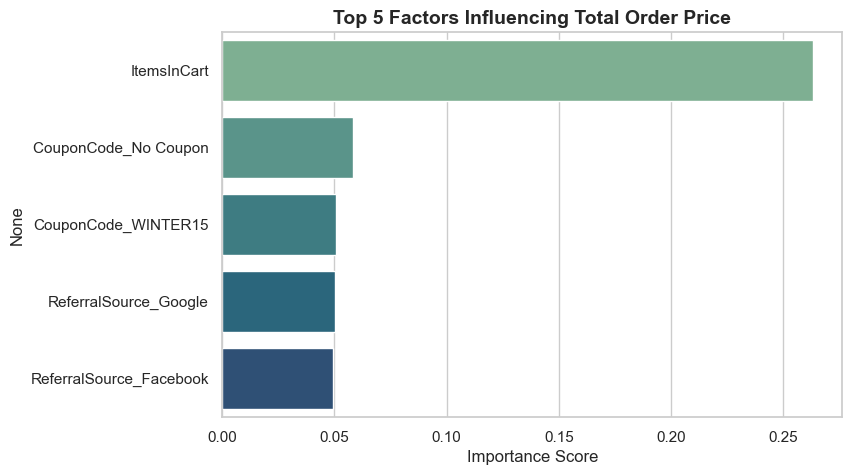

In [76]:
# Feature Importance (Business Insight)
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(5)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='crest', hue=importances.index, legend=False)
plt.title('Top 5 Factors Influencing Total Order Price', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.show()